## DLinear

In [ ]:
# ── Colab / Local setup ──────────────────────────────────────────────────
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1. Clone the repo
    import subprocess
    subprocess.run(["git", "clone", "https://github.com/DaTking4/ml-final-project-walmart-recruiting.git"], check=True)
    %cd ml-final-project-walmart-recruiting

    # 2. Install dependencies
    %pip install -q -r requirements.txt

    # 3. Inject Colab secrets as environment variables
    import os
    from google.colab import userdata
    os.environ["DAGSHUB_USER_TOKEN"] = userdata.get("DAGSHUB_TOKEN")
    os.environ["WANDB_API_KEY"]    = userdata.get("WANDB_API_KEY")
    os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

    # 4. Download competition data
    %pip install -q kaggle
    import os
    os.makedirs("data", exist_ok=True)
    !kaggle competitions download -c walmart-recruiting-store-sales-forecasting -p data/ --quiet
    !unzip -q -o data/walmart-recruiting-store-sales-forecasting.zip -d data/

print("Running in:", "Google Colab" if IN_COLAB else "Local environment")


### 1. Setup and Imports

In [1]:
import os
import sys
import importlib
from pathlib import Path

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))
os.environ.setdefault("NIXTLA_ID_AS_COL", "1")
repo_root = Path.cwd()
while repo_root != repo_root.parent:
    if (repo_root / "src").exists():
        sys.path.insert(0, str(repo_root))
        break
    repo_root = repo_root.parent
else:
    raise FileNotFoundError("Could not locate the repository root containing 'src'.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.pyfunc
from mlflow.models import infer_signature

import wandb

from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear

import src.mlflow_setup as mlflow_setup
importlib.reload(mlflow_setup)
init_tracking = mlflow_setup.init_tracking
from src.data_loading import load_merged
from src.transforms import apply_shared_features
from src.validation import time_based_split
from src.metrics import wmae_from_df
from src.pipeline.dlinear_pipeline import to_long_format, DLinearForecastPipeline
from src.training_diagnostics import GradientNormLogger, log_gradient_diagnostics

init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

print("Current MLflow URI:", mlflow.get_tracking_uri())

if mlflow.active_run() is not None:
    mlflow.end_run()

BLUE   = "#7196C7"
PINK   = "#AE737D"
PURPLE = "#705588"
RED    = "#7E3838"
GREEN  = "#5E9D74"

REGIME_COLORS = {
    "underfit": PURPLE,
    "balanced": BLUE,
    "overfit": RED,
}

STATUS_COLORS = {
    "good": GREEN,
    "underfit": PURPLE,
    "overfit": RED,
}

print("Setup complete.")


/Users/macbookpro/Desktop/ml-final-project-walmart-recruiting/.venv311/lib/python3.11/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/Users/macbookpro/Desktop/ml-final-project-walmart-recruiting/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-11 22:44:47,357	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-07-11 22:44:47,503	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook o

Accessing as lchit22

Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Current MLflow URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Setup complete.


### 2. Configuration

In [2]:
init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

EXPERIMENT_NAME = "DLinear_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

WANDB_ENTITY = "dkhak22-free-university-of-tbilisi-"
WANDB_PROJECT = "walmart-sales-forecasting"

CONFIG = {
    "input_size": 52,
    "horizon": 26,
    "moving_avg_window": 13,
    "batch_size": 128,
    "learning_rate": 1e-3,
    "max_steps": 500,
    "random_seed": 42,
}

FREQ = "W-FRI"

CONFIG


Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow


{'input_size': 52,
 'horizon': 26,
 'moving_avg_window': 13,
 'batch_size': 128,
 'learning_rate': 0.001,
 'max_steps': 500,
 'random_seed': 42}

### 3. Load data

In [3]:
train_df, test_df = load_merged()

print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")

CONFIG["horizon"] = test_df["Date"].nunique()

train_df.head()


train_df: (421570, 16)
test_df:  (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


### 4. Shared Preprocessing and Feature Engineering

In [4]:
train_feat = apply_shared_features(train_df)

print(f"Columns after shared feature engineering: {train_feat.shape[1]}")
train_feat.head()


Columns after shared feature engineering: 23


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Size,Type_A,Type_B,Type_C,Year,Month,WeekOfYear,DaysSinceLastHoliday,DaysToNextHoliday
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,5,inf,7.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,6,0.0,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,7,7.0,203.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,8,14.0,196.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,3,9,21.0,189.0


### 5. Model Specific Feature Engineering

In [5]:
long_df = to_long_format(
    train_feat,
    include_target=True,
)

future_df = to_long_format(
    test_df,
    include_target=False,
)

print(f"long_df shape: {long_df.shape}")
print(f"future_df shape: {future_df.shape}")
print(f"number of time series: {long_df['unique_id'].nunique()}")

print("\nColumns used by DLinear:")
print(long_df.columns.tolist())

print("\nFuture dataframe kept only for checking, not as model input:")
print(future_df.columns.tolist())

print("\nExample series:")
example_id = long_df["unique_id"].iloc[0]
display(long_df[long_df["unique_id"] == example_id].head(10))


long_df shape: (421570, 3)
future_df shape: (115064, 2)
number of time series: 3331

Columns used by DLinear:
['unique_id', 'ds', 'y']

Future dataframe kept only for checking, not as model input:
['unique_id', 'ds']

Example series:


,unique_id,ds,y
0,10_1,2010-02-05,40212.84
1,10_1,2010-02-12,67699.32
2,10_1,2010-02-19,49748.33
3,10_1,2010-02-26,33601.22
4,10_1,2010-03-05,36572.44
5,10_1,2010-03-12,36380.70
6,10_1,2010-03-19,38252.33
7,10_1,2010-03-26,51956.73
8,10_1,2010-04-02,131853.01
9,10_1,2010-04-09,89207.79


### 6. Feature Selection

In [6]:
exogenous_support = {
    "future_exogenous": getattr(DLinear, "EXOGENOUS_FUTR", False),
    "historical_exogenous": getattr(DLinear, "EXOGENOUS_HIST", False),
    "static_exogenous": getattr(DLinear, "EXOGENOUS_STAT", False),
}

display(pd.Series(exogenous_support, name="DLinear exogenous support"))

DLINEAR_FEATURE_DECISION = {
    "feature_set": "target_history_only",
    "uses_exogenous_features": False,
    "used_model_columns": "unique_id, ds, y",
    "reason": (
        "The NeuralForecast DLinear implementation does not support future, "
        "historical, or static exogenous variables. Therefore, this DLinear "
        "experiment uses only historical Weekly_Sales for each Store-Dept series."
    ),
}

DLINEAR_FEATURE_DECISION


future_exogenous        False
historical_exogenous    False
static_exogenous        False
Name: DLinear exogenous support, dtype: bool

{'feature_set': 'target_history_only',
 'uses_exogenous_features': False,
 'used_model_columns': 'unique_id, ds, y',
 'reason': 'The NeuralForecast DLinear implementation does not support future, historical, or static exogenous variables. Therefore, this DLinear experiment uses only historical Weekly_Sales for each Store-Dept series.'}

### 7. Time-Series and Window Setup

In [7]:

train_part, valid_part = time_based_split(
    train_feat,
    valid_weeks=CONFIG["horizon"]
)

print(f"Train part: {train_part['Date'].min().date()} -> {train_part['Date'].max().date()}")
print(f"Valid part: {valid_part['Date'].min().date()} -> {valid_part['Date'].max().date()}")

print(f"\nInput size: {CONFIG['input_size']} weeks")
print(f"Forecast horizon: {CONFIG['horizon']} weeks")

series_lengths = long_df.groupby("unique_id").size()

DLINEAR_SERIES_LENGTH = int(series_lengths.max())
dlinear_ids = series_lengths[series_lengths == DLINEAR_SERIES_LENGTH].index
dlinear_df = long_df[long_df["unique_id"].isin(dlinear_ids)].copy()

print("\nSeries length summary:")
display(series_lengths.describe())

print("\nShortest series length:", series_lengths.min())
print("Longest series length:", series_lengths.max())
print("Number of series shorter than input_size:", (series_lengths < CONFIG["input_size"]).sum())
print(
    "Number of series shorter than input_size + horizon:",
    (series_lengths < (CONFIG["input_size"] + CONFIG["horizon"])).sum(),
)

print("\nDLinear training/evaluation frame:")
print(f"Using {dlinear_df['unique_id'].nunique()} complete-history series")
print(f"Dropping {long_df['unique_id'].nunique() - dlinear_df['unique_id'].nunique()} ragged/short series")
print(f"Rows used by DLinear: {dlinear_df.shape[0]:,}")

# NeuralForecast 1.7.6 DLinear cross_validation can segfault on very short/ragged
# histories, and predict_insample requires compatible series lengths. Keep the
# model experiment on complete Store-Dept histories so train/validation metrics
# are computed on the same stable population.

def ensure_unique_id_column(df):
    if "unique_id" not in df.columns and df.index.name == "unique_id":
        return df.reset_index()
    return df


def fit_gap_pct(train_wmae, val_wmae):
    if pd.isna(train_wmae) or train_wmae == 0:
        return np.nan
    return ((val_wmae - train_wmae) / train_wmae) * 100


def classify_fit_status(train_wmae, val_wmae):
    gap = fit_gap_pct(train_wmae, val_wmae)
    if pd.isna(gap):
        return "unknown"
    if gap > 25:
        return "overfit"
    if gap < -10:
        return "underfit"
    return "good"

def save_neuralforecast_model(nf_model, path, overwrite=True, save_dataset=True):
    # NeuralForecast 1.7.x can miss these attrs when no prediction intervals are used.
    if not hasattr(nf_model, "prediction_intervals"):
        nf_model.prediction_intervals = None
    if not hasattr(nf_model, "_cs_df"):
        nf_model._cs_df = None
    nf_model.save(path=path, overwrite=overwrite, save_dataset=save_dataset)


Train part: 2010-02-05 -> 2012-01-27
Valid part: 2012-02-03 -> 2012-10-26

Input size: 52 weeks
Forecast horizon: 39 weeks

Series length summary:


count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
dtype: float64


Shortest series length: 1
Longest series length: 143
Number of series shorter than input_size: 340
Number of series shorter than input_size + horizon: 431

DLinear training/evaluation frame:
Using 2660 complete-history series
Dropping 671 ragged/short series
Rows used by DLinear: 380,380


### 8. Forward and Backward Check

In [8]:
tiny_ids = long_df["unique_id"].unique()[:5]
tiny_df = long_df[long_df["unique_id"].isin(tiny_ids)]

sanity_model = DLinear(
    h=CONFIG["horizon"],
    input_size=CONFIG["input_size"],
    moving_avg_window=CONFIG["moving_avg_window"],
    max_steps=2,
    batch_size=8,
    learning_rate=CONFIG["learning_rate"],
    random_seed=CONFIG["random_seed"],
    start_padding_enabled=True,
    scaler_type="robust",
    accelerator="cpu",
    devices=1,
)

sanity_nf = NeuralForecast(models=[sanity_model], freq=FREQ)

print("Testing DLinear target-history-only setup...")

sanity_cv = sanity_nf.cross_validation(
    df=tiny_df,
    n_windows=1,
    step_size=CONFIG["horizon"],
)

expected_rows = len(tiny_ids) * CONFIG["horizon"]

assert len(sanity_cv) == expected_rows
assert sanity_cv["DLinear"].notna().all()

print("Forward/backward sanity check passed:", sanity_cv.shape)
display(sanity_cv.head())


Seed set to 42
/Users/macbookpro/Desktop/ml-final-project-walmart-recruiting/.venv311/lib/python3.11/site-packages/neuralforecast/common/_base_model.py:359: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Testing DLinear target-history-only setup...



  | Name          | Type          | Params
------------------------------------------------
0 | loss          | MAE           | 0     
1 | padder_train  | ConstantPad1d | 0     
2 | scaler        | TemporalNorm  | 0     
3 | decomp        | SeriesDecomp  | 0     
4 | linear_trend  | Linear        | 2.1 K 
5 | linear_season | Linear        | 2.1 K 
------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Total estimated model params size (MB)


Epoch 1: 100%|██████████| 1/1 [00:00<00:00, 138.60it/s, v_num=106, train_loss_step=192.0, train_loss_epoch=192.0]

`Trainer.fit` stopped: `max_steps=2` reached.


Epoch 1: 100%|██████████| 1/1 [00:00<00:00, 124.57it/s, v_num=106, train_loss_step=192.0, train_loss_epoch=192.0]

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 460.56it/s]
Forward/backward sanity check passed: (195, 5)


,unique_id,ds,cutoff,DLinear,y
0,10_1,2012-02-03,2012-01-27,49631.359375,36444.00
1,10_1,2012-02-10,2012-01-27,36783.453125,50434.11
2,10_1,2012-02-17,2012-01-27,-2698.476562,74930.33
3,10_1,2012-02-24,2012-01-27,38624.492188,28751.57
4,10_1,2012-03-02,2012-01-27,23157.677734,30525.88


### 9. Baseline Run

In [9]:

holiday_lookup = train_feat.assign(
    unique_id=train_feat["Store"].astype(str) + "_" + train_feat["Dept"].astype(str),
    ds=train_feat["Date"],
)[["unique_id", "ds", "IsHoliday"]].drop_duplicates()

holiday_lookup["IsHoliday"] = holiday_lookup["IsHoliday"].fillna(False).astype(bool)

display(holiday_lookup.head())


with mlflow.start_run(run_name="DLinear_Baseline") as run:
    wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name="DLinear_Baseline",
        group="DLinear",
        job_type="baseline",
        tags=["DLinear", "baseline", "target_history_only"],
        config={
            **CONFIG,
            "feature_set": DLINEAR_FEATURE_DECISION["feature_set"],
            "uses_exogenous_features": DLINEAR_FEATURE_DECISION["uses_exogenous_features"],
            "dlinear_series_length": DLINEAR_SERIES_LENGTH,
            "dlinear_n_series": dlinear_df["unique_id"].nunique(),
        },
        reinit=True,
    )

    try:
        gradient_callback = GradientNormLogger(log_every_n_steps=10)
        baseline_model = DLinear(
            h=CONFIG["horizon"],
            input_size=CONFIG["input_size"],
            moving_avg_window=CONFIG["moving_avg_window"],
            max_steps=CONFIG["max_steps"],
            batch_size=CONFIG["batch_size"],
            learning_rate=CONFIG["learning_rate"],
            random_seed=CONFIG["random_seed"],
            start_padding_enabled=True,
            scaler_type="robust",
            accelerator="cpu",
            devices=1,
            callbacks=[gradient_callback],
        )

        baseline_nf = NeuralForecast(models=[baseline_model], freq=FREQ)

        cv_df = baseline_nf.cross_validation(
            df=dlinear_df,
            n_windows=1,
            step_size=CONFIG["horizon"],
        )
        cv_df = ensure_unique_id_column(cv_df)

        cv_df = cv_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
        cv_df["IsHoliday"] = cv_df["IsHoliday"].fillna(False).astype(bool)

        val_wmae = wmae_from_df(
            cv_df,
            y_true_col="y",
            y_pred_col="DLinear",
            holiday_col="IsHoliday",
        )

        train_pred_df = baseline_nf.predict_insample(step_size=CONFIG["horizon"])
        train_pred_df = ensure_unique_id_column(train_pred_df)
        train_pred_df = train_pred_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
        train_pred_df["IsHoliday"] = train_pred_df["IsHoliday"].fillna(False).astype(bool)

        train_wmae = wmae_from_df(
            train_pred_df,
            y_true_col="y",
            y_pred_col="DLinear",
            holiday_col="IsHoliday",
        )

        gap_pct = fit_gap_pct(train_wmae, val_wmae)
        fit_status = classify_fit_status(train_wmae, val_wmae)

        print(f"Baseline train WMAE: {train_wmae:,.2f}")
        print(f"Baseline val WMAE:   {val_wmae:,.2f}")
        print(f"Baseline gap:        {gap_pct:,.2f}% ({fit_status})")

        mlflow.log_params(CONFIG)
        mlflow.log_params({
            "feature_set": DLINEAR_FEATURE_DECISION["feature_set"],
            "uses_exogenous_features": DLINEAR_FEATURE_DECISION["uses_exogenous_features"],
            "dlinear_series_length": DLINEAR_SERIES_LENGTH,
            "dlinear_n_series": dlinear_df["unique_id"].nunique(),
            "dlinear_dropped_series": long_df["unique_id"].nunique() - dlinear_df["unique_id"].nunique(),
        })

        mlflow.log_metric("train_wmae", train_wmae)
        mlflow.log_metric("val_wmae", val_wmae)
        mlflow.log_metric("gap_pct", gap_pct)
        mlflow.log_param("fit_status", fit_status)
        mlflow.log_param("gradient_logging", True)
        gradient_metrics = log_gradient_diagnostics(
            gradient_callback,
            model_name="DLinear",
            run_label="baseline",
            mlflow_module=mlflow,
            wandb_module=wandb,
        )

        wandb.log({
            "train_wmae": train_wmae,
            "val_wmae": val_wmae,
            "gap_pct": gap_pct,
            "fit_status": fit_status,
        })

        os.makedirs("artifacts", exist_ok=True)

        baseline_path = "artifacts/dlinear_baseline"
        save_neuralforecast_model(baseline_nf, path=baseline_path, overwrite=True)

        mlflow.log_artifacts(
            baseline_path,
            artifact_path="nf_model",
        )

        baseline_run_id = run.info.run_id

    finally:
        wandb.finish()


,unique_id,ds,IsHoliday
0,1_1,2010-02-05,False
1,1_1,2010-02-12,True
2,1_1,2010-02-19,False
3,1_1,2010-02-26,False
4,1_1,2010-03-05,False


wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: lchit22 (dkhak22-free-university-of-tbilisi-). Use `wandb login --relogin` to force relogin
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
Seed set to 42
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name          | Type          | Params
------------------------------------------------
0 | loss          | MAE           | 0     
1 | padder_train  | ConstantPad1d | 0     
2 | scaler        | TemporalNorm  | 

Epoch 23:  81%|████████  | 17/21 [00:00<00:00, 117.93it/s, v_num=108, train_loss_step=92.20, train_loss_epoch=49.30]

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 23:  81%|████████  | 17/21 [00:00<00:00, 117.21it/s, v_num=108, train_loss_step=92.20, train_loss_epoch=49.30]


Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 21/21 [00:00<00:00, 668.56it/s]


Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 21/21 [00:00<00:00, 613.03it/s]
Baseline train WMAE: 11,235.24
Baseline val WMAE:   2,555.44
Baseline gap:        -77.26% (underfit)


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
2026/07/11 22:45:53 INFO mlflow.tracking._tracking_service.client: 🏃 View run DLinear_Baseline at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/0/runs/6a63c07992bf4151a4117d1e7a8f8230.
2026/07/11 22:45:53 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/0.


### 10. Hyperparameters

In [10]:
param_grid = [
    {"input_size": 13, "moving_avg_window": 5, "max_steps": 10, "learning_rate": 1e-6, "batch_size": 128, "label": "underfit_1", "regime": "underfit"},
    {"input_size": 13, "moving_avg_window": 5, "max_steps": 30, "learning_rate": 1e-5, "batch_size": 128, "label": "underfit_2", "regime": "underfit"},
    {"input_size": 26, "moving_avg_window": 9, "max_steps": 10, "learning_rate": 1e-6, "batch_size": 128, "label": "underfit_3", "regime": "underfit"},
    {"input_size": 26, "moving_avg_window": 9, "max_steps": 30, "learning_rate": 1e-5, "batch_size": 128, "label": "underfit_4", "regime": "underfit"},
    {"input_size": 13, "moving_avg_window": 9, "max_steps": 60, "learning_rate": 1e-6, "batch_size": 128, "label": "underfit_5", "regime": "underfit"},
    {"input_size": 26, "moving_avg_window": 5, "max_steps": 60, "learning_rate": 1e-5, "batch_size": 128, "label": "underfit_6", "regime": "underfit"},

    {"input_size": 52, "moving_avg_window": 13, "max_steps": 300, "learning_rate": 1e-3, "batch_size": 64, "label": "balanced_1", "regime": "balanced"},
    {"input_size": 52, "moving_avg_window": 13, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_2", "regime": "balanced"},
    {"input_size": 52, "moving_avg_window": 25, "max_steps": 300, "learning_rate": 1e-3, "batch_size": 64, "label": "balanced_3", "regime": "balanced"},
    {"input_size": 52, "moving_avg_window": 25, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_4", "regime": "balanced"},
    {"input_size": 52, "moving_avg_window": 25, "max_steps": 800, "learning_rate": 5e-4, "batch_size": 128, "label": "balanced_5", "regime": "balanced"},
    {"input_size": 52, "moving_avg_window": 39, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_6", "regime": "balanced"},
    {"input_size": 78, "moving_avg_window": 13, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 64, "label": "balanced_7", "regime": "balanced"},
    {"input_size": 78, "moving_avg_window": 25, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_8", "regime": "balanced"},
    {"input_size": 78, "moving_avg_window": 25, "max_steps": 800, "learning_rate": 5e-4, "batch_size": 128, "label": "balanced_9", "regime": "balanced"},
    {"input_size": 78, "moving_avg_window": 39, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 64, "label": "balanced_10", "regime": "balanced"},
    {"input_size": 104, "moving_avg_window": 25, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_11", "regime": "balanced"},
    {"input_size": 104, "moving_avg_window": 25, "max_steps": 800, "learning_rate": 5e-4, "batch_size": 128, "label": "balanced_12", "regime": "balanced"},
    {"input_size": 104, "moving_avg_window": 39, "max_steps": 500, "learning_rate": 1e-3, "batch_size": 64, "label": "balanced_13", "regime": "balanced"},
    {"input_size": 104, "moving_avg_window": 51, "max_steps": 800, "learning_rate": 5e-4, "batch_size": 128, "label": "balanced_14", "regime": "balanced"},
    {"input_size": 52, "moving_avg_window": 25, "max_steps": 500, "learning_rate": 5e-4, "batch_size": 64, "label": "balanced_15", "regime": "balanced"},
    {"input_size": 52, "moving_avg_window": 25, "max_steps": 500, "learning_rate": 2e-3, "batch_size": 128, "label": "balanced_16", "regime": "balanced"},
    {"input_size": 78, "moving_avg_window": 25, "max_steps": 300, "learning_rate": 1e-3, "batch_size": 128, "label": "balanced_17", "regime": "balanced"},
    {"input_size": 104, "moving_avg_window": 25, "max_steps": 300, "learning_rate": 1e-3, "batch_size": 64, "label": "balanced_18", "regime": "balanced"},

    {"input_size": 130, "moving_avg_window": 51, "max_steps": 2000, "learning_rate": 2e-2, "batch_size": 8, "label": "overfit_1", "regime": "overfit"},
    {"input_size": 130, "moving_avg_window": 77, "max_steps": 4000, "learning_rate": 5e-2, "batch_size": 8, "label": "overfit_2", "regime": "overfit"},
    {"input_size": 156, "moving_avg_window": 51, "max_steps": 2000, "learning_rate": 2e-2, "batch_size": 16, "label": "overfit_3", "regime": "overfit"},
    {"input_size": 156, "moving_avg_window": 77, "max_steps": 4000, "learning_rate": 5e-2, "batch_size": 16, "label": "overfit_4", "regime": "overfit"},
    {"input_size": 182, "moving_avg_window": 51, "max_steps": 2000, "learning_rate": 5e-2, "batch_size": 8, "label": "overfit_5", "regime": "overfit"},
    {"input_size": 182, "moving_avg_window": 77, "max_steps": 4000, "learning_rate": 2e-2, "batch_size": 16, "label": "overfit_6", "regime": "overfit"},
]

print(f"Total DLinear configs: {len(param_grid)}")


Total DLinear configs: 30


### 11. DLinear Experiments

In [ ]:

results = []
cv_by_label = {}

best_val_wmae = float("inf")
best_run_id = None
best_label = None
best_nf_path = None

with mlflow.start_run(run_name="DLinear_HyperparamSweep") as parent_run:
    mlflow.log_param("n_configs", len(param_grid))
    mlflow.log_param("model", "DLinear")
    mlflow.log_param("feature_set", DLINEAR_FEATURE_DECISION["feature_set"])
    mlflow.log_param("dlinear_series_length", DLINEAR_SERIES_LENGTH)
    mlflow.log_param("dlinear_n_series", dlinear_df["unique_id"].nunique())

    for original_params in param_grid:
        params = original_params.copy()

        label = params.pop("label")
        regime = params.pop("regime")

        with mlflow.start_run(run_name=f"DLinear_{label}", nested=True) as nested_run:
            wandb.init(
                entity=WANDB_ENTITY,
                project=WANDB_PROJECT,
                name=f"DLinear_{label}",
                group="DLinear",
                job_type="hyperparameter_sweep",
                tags=["DLinear", regime, "target_history_only"],
                config={
                    **params,
                    "regime": regime,
                    "feature_set": DLINEAR_FEATURE_DECISION["feature_set"],
                    "uses_exogenous_features": DLINEAR_FEATURE_DECISION["uses_exogenous_features"],
                    "dlinear_series_length": DLINEAR_SERIES_LENGTH,
                    "dlinear_n_series": dlinear_df["unique_id"].nunique(),
                },
                reinit=True,
            )

            try:
                gradient_callback = GradientNormLogger(log_every_n_steps=10)
                model = DLinear(
                    h=CONFIG["horizon"],
                    input_size=params["input_size"],
                    moving_avg_window=params["moving_avg_window"],
                    max_steps=params["max_steps"],
                    learning_rate=params["learning_rate"],
                    batch_size=params["batch_size"],
                    random_seed=CONFIG["random_seed"],
                    start_padding_enabled=True,
                    scaler_type="robust",
                    accelerator="cpu",
                    devices=1,
                    callbacks=[gradient_callback],
                )

                nf = NeuralForecast(models=[model], freq=FREQ)

                cv_df = nf.cross_validation(
                    df=dlinear_df,
                    n_windows=1,
                    step_size=CONFIG["horizon"],
                )
                cv_df = ensure_unique_id_column(cv_df)

                cv_df = cv_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
                cv_df["IsHoliday"] = cv_df["IsHoliday"].fillna(False).astype(bool)

                val_wmae = wmae_from_df(
                    cv_df,
                    y_true_col="y",
                    y_pred_col="DLinear",
                    holiday_col="IsHoliday",
                )

                train_pred_df = nf.predict_insample(step_size=CONFIG["horizon"])
                train_pred_df = ensure_unique_id_column(train_pred_df)
                train_pred_df = train_pred_df.merge(holiday_lookup, on=["unique_id", "ds"], how="left")
                train_pred_df["IsHoliday"] = train_pred_df["IsHoliday"].fillna(False).astype(bool)

                train_wmae = wmae_from_df(
                    train_pred_df,
                    y_true_col="y",
                    y_pred_col="DLinear",
                    holiday_col="IsHoliday",
                )

                gap_pct = fit_gap_pct(train_wmae, val_wmae)
                fit_status = classify_fit_status(train_wmae, val_wmae)

                cv_by_label[label] = cv_df.copy()

                mlflow.log_params({
                    **params,
                    "regime": regime,
                    "label": label,
                    "feature_set": DLINEAR_FEATURE_DECISION["feature_set"],
                    "uses_exogenous_features": DLINEAR_FEATURE_DECISION["uses_exogenous_features"],
                    "n_exog_cols": 0,
                    "dlinear_series_length": DLINEAR_SERIES_LENGTH,
                    "dlinear_n_series": dlinear_df["unique_id"].nunique(),
                })

                mlflow.log_metric("train_wmae", train_wmae)
                mlflow.log_metric("val_wmae", val_wmae)
                mlflow.log_metric("gap_pct", gap_pct)
                mlflow.log_param("fit_status", fit_status)
                mlflow.log_param("gradient_logging", True)
                gradient_metrics = log_gradient_diagnostics(
                    gradient_callback,
                    model_name="DLinear",
                    run_label=label,
                    mlflow_module=mlflow,
                    wandb_module=wandb,
                )

                wandb.log({
                    "train_wmae": train_wmae,
                    "val_wmae": val_wmae,
                    "gap_pct": gap_pct,
                    "fit_status": fit_status,
                })

                results.append({
                    "label": label,
                    "regime": regime,
                    **params,
                    "feature_set": DLINEAR_FEATURE_DECISION["feature_set"],
                    "train_wmae": train_wmae,
                    "val_wmae": val_wmae,
                    "gap_pct": gap_pct,
                    "status": fit_status,
                    **gradient_metrics,
                    "run_id": nested_run.info.run_id,
                })

                if val_wmae < best_val_wmae:
                    best_val_wmae = val_wmae
                    best_run_id = nested_run.info.run_id
                    best_label = label

                    best_nf_path = f"artifacts/dlinear_{label}"
                    save_neuralforecast_model(nf, path=best_nf_path, overwrite=True)

                    mlflow.log_artifacts(
                        best_nf_path,
                        artifact_path="nf_model",
                    )

                    print(
                        f"New best: {best_label} | "
                        f"train WMAE = {train_wmae:,.2f} | "
                        f"val WMAE = {best_val_wmae:,.2f} | "
                        f"gap = {gap_pct:,.2f}% ({fit_status})"
                    )

            finally:
                wandb.finish()


### 12. Results

In [12]:

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("val_wmae").reset_index(drop=True)

display_cols = [
    "label",
    "regime",
    "status",
    "feature_set",
    "input_size",
    "moving_avg_window",
    "max_steps",
    "learning_rate",
    "batch_size",
    "grad_total_norm_mean",
    "grad_total_norm_max",
    "grad_total_norm_last",
    "train_wmae",
    "val_wmae",
    "gap_pct",
]

display(results_df[display_cols].head(15))

os.makedirs("reports", exist_ok=True)

results_path = "reports/dlinear_results.csv"
results_df.to_csv(results_path, index=False)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(results_path)


,label,regime,status,feature_set,input_size,moving_avg_window,max_steps,learning_rate,batch_size,grad_total_norm_mean,grad_total_norm_max,grad_total_norm_last,train_wmae,val_wmae,gap_pct
0,balanced_2,balanced,underfit,target_history_only,52,13,500,0.0010,128,0.0,0.0,0.0,11235.241791,2555.443176,-77.255112
1,balanced_1,balanced,underfit,target_history_only,52,13,300,0.0010,64,0.0,0.0,0.0,11457.574709,2605.109029,-77.262998
2,balanced_7,balanced,underfit,target_history_only,78,13,500,0.0010,64,0.0,0.0,0.0,10990.891181,2641.008219,-75.970937
3,balanced_16,balanced,underfit,target_history_only,52,25,500,0.0020,128,0.0,0.0,0.0,10859.962856,2676.600888,-75.353499
4,balanced_10,balanced,underfit,target_history_only,78,39,500,0.0010,64,0.0,0.0,0.0,10875.471751,2741.548184,-74.791455
5,balanced_17,balanced,underfit,target_history_only,78,25,300,0.0010,128,0.0,0.0,0.0,10979.873553,2751.093114,-74.944219
6,balanced_4,balanced,underfit,target_history_only,52,25,500,0.0010,128,0.0,0.0,0.0,11071.639534,2762.178028,-75.051771
7,balanced_5,balanced,underfit,target_history_only,52,25,800,0.0005,128,0.0,0.0,0.0,11141.951056,2772.158073,-75.119635
8,balanced_9,balanced,underfit,target_history_only,78,25,800,0.0005,128,0.0,0.0,0.0,10856.351026,2781.117582,-74.382575
9,balanced_8,balanced,underfit,target_history_only,78,25,500,0.0010,128,0.0,0.0,0.0,10844.149550,2781.224463,-74.352766


2026/07/11 23:05:30 INFO mlflow.tracking._tracking_service.client: 🏃 View run DLinear_balanced_2 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/0/runs/55271adeb50e4787a6ab3f781145e628.
2026/07/11 23:05:30 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/0.


### 13. Plots

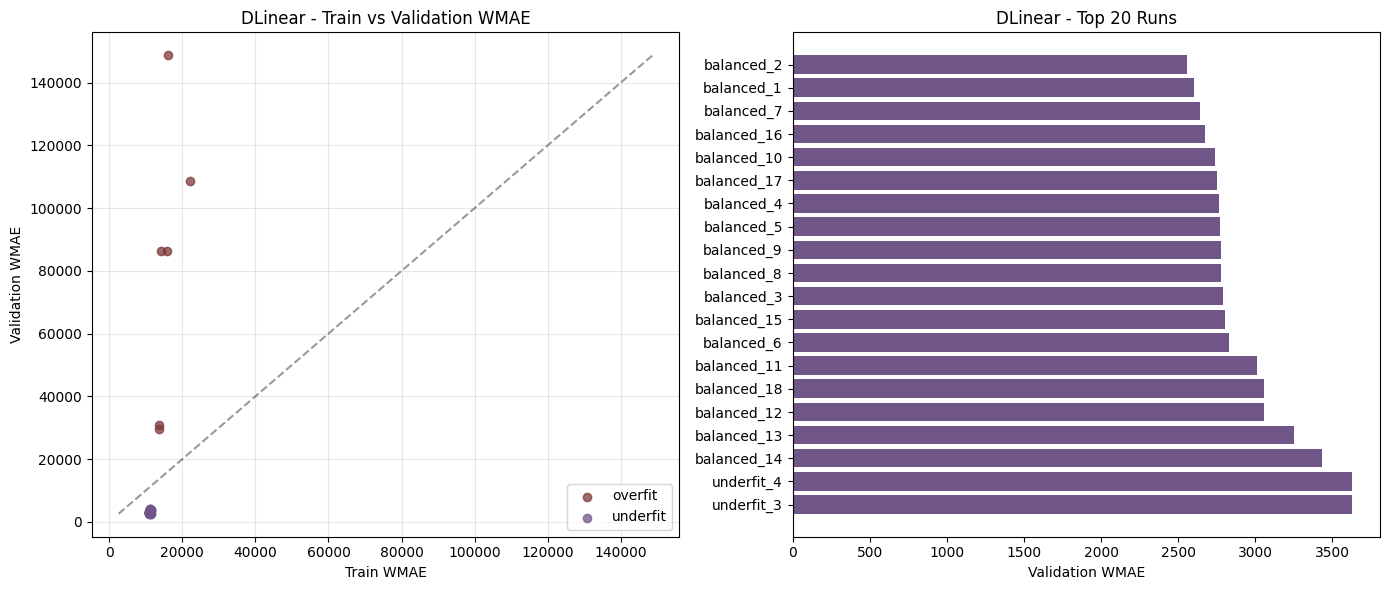

2026/07/11 23:05:35 INFO mlflow.tracking._tracking_service.client: 🏃 View run DLinear_balanced_2 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/0/runs/55271adeb50e4787a6ab3f781145e628.
2026/07/11 23:05:35 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/0.
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't imp

In [13]:

os.makedirs("Plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for status, status_df in results_df.groupby("status"):
    axes[0].scatter(
        status_df["train_wmae"],
        status_df["val_wmae"],
        c=STATUS_COLORS.get(status, BLUE),
        alpha=0.75,
        label=status,
    )

min_wmae = float(results_df[["train_wmae", "val_wmae"]].min().min())
max_wmae = float(results_df[["train_wmae", "val_wmae"]].max().max())
axes[0].plot([min_wmae, max_wmae], [min_wmae, max_wmae], color="black", linestyle="--", alpha=0.4)
axes[0].set_xlabel("Train WMAE")
axes[0].set_ylabel("Validation WMAE")
axes[0].set_title("DLinear - Train vs Validation WMAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

top20 = results_df.head(20)

axes[1].barh(
    top20["label"],
    top20["val_wmae"],
    color=top20["status"].map(lambda status: STATUS_COLORS.get(status, BLUE)),
)

axes[1].invert_yaxis()
axes[1].set_xlabel("Validation WMAE")
axes[1].set_title("DLinear - Top 20 Runs")

plt.tight_layout()

plot_path = "Plots/dlinear_wmae_comparison.png"
plt.savefig(plot_path, dpi=200)
wandb_plot_path = plot_path
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(plot_path)

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="DLinear_Analysis",
    group="DLinear",
    job_type="analysis",
    tags=["DLinear", "analysis", "charts", "train_validation_gap"],
    reinit=True,
)

wandb.log({
    "dlinear_wmae_comparison": wandb.Image(wandb_plot_path),
    "best_val_wmae": best_val_wmae,
    "best_train_wmae": float(results_df.loc[results_df["label"] == best_label, "train_wmae"].iloc[0]),
    "best_gap_pct": float(results_df.loc[results_df["label"] == best_label, "gap_pct"].iloc[0]),
})

wandb.finish()


### 14. Error Analysis

In [14]:
best_cv_df = cv_by_label[best_label].copy()

best_cv_df["abs_error"] = (best_cv_df["y"] - best_cv_df["DLinear"]).abs()
best_cv_df[["Store", "Dept"]] = best_cv_df["unique_id"].str.split("_", n=1, expand=True)

display(best_cv_df.head())

worst_store_dept = (
    best_cv_df
    .groupby(["Store", "Dept"])["abs_error"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

display(worst_store_dept)

holiday_error = best_cv_df.groupby("IsHoliday")["abs_error"].mean()

display(holiday_error)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_metric("holiday_week_mae", float(holiday_error.get(True, np.nan)))
    mlflow.log_metric("nonholiday_week_mae", float(holiday_error.get(False, np.nan)))


,unique_id,ds,cutoff,DLinear,y,IsHoliday,abs_error,Store,Dept
0,10_1,2012-02-03,2012-01-27,29610.503906,36444.00,False,6833.496094,10,1
1,10_1,2012-02-10,2012-01-27,40453.484375,50434.11,True,9980.625625,10,1
2,10_1,2012-02-17,2012-01-27,32497.597656,74930.33,False,42432.732344,10,1
3,10_1,2012-02-24,2012-01-27,39844.789062,28751.57,False,11093.219063,10,1
4,10_1,2012-03-02,2012-01-27,19854.734375,30525.88,False,10671.145625,10,1


Store  Dept
10     72      30301.216883
14     92      24275.270529
20     72      23137.826855
35     72      22371.969796
18     92      22239.955501
19     16      21264.280796
38     38      21049.923594
20     16      20299.045090
14     95      20079.655176
       72      19384.267292
23     16      19207.253694
27     72      18566.770082
10     7       18301.281098
14     16      18067.353478
4      72      18048.868550
Name: abs_error, dtype: float64

IsHoliday
False    2565.985999
True     2516.434729
Name: abs_error, dtype: float64

2026/07/11 23:05:54 INFO mlflow.tracking._tracking_service.client: 🏃 View run DLinear_balanced_2 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/0/runs/55271adeb50e4787a6ab3f781145e628.
2026/07/11 23:05:54 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/0.


### 15. Error Plots

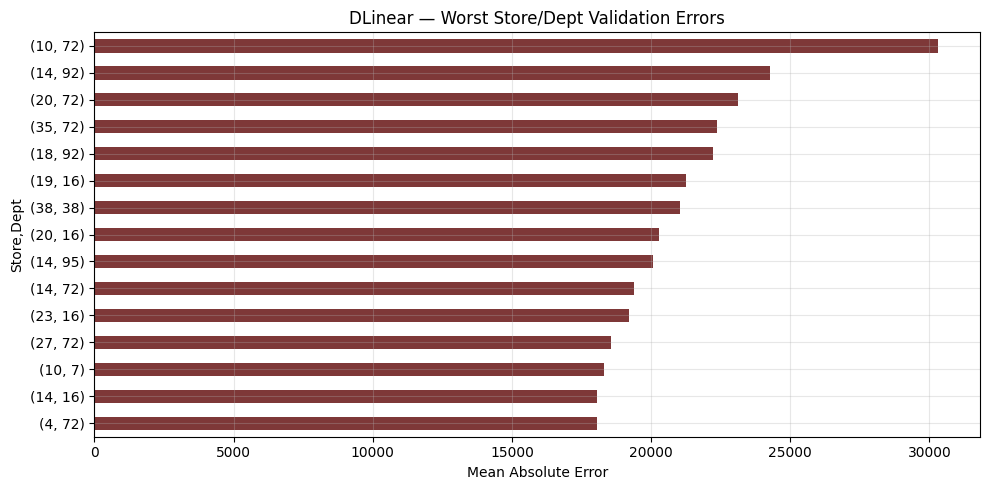

2026/07/11 23:06:01 INFO mlflow.tracking._tracking_service.client: 🏃 View run DLinear_balanced_2 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/0/runs/55271adeb50e4787a6ab3f781145e628.
2026/07/11 23:06:01 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/0.
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't imp

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

worst_store_dept.sort_values().plot(
    kind="barh",
    ax=ax,
    color=RED,
)

ax.set_xlabel("Mean Absolute Error")
ax.set_title("DLinear — Worst Store/Dept Validation Errors")
ax.grid(True, alpha=0.3)

plt.tight_layout()

error_plot_path = "Plots/dlinear_worst_store_dept.png"
plt.savefig(error_plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(error_plot_path)

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="DLinear_Error_Analysis",
    group="DLinear",
    job_type="analysis",
    tags=["DLinear", "error_analysis"],
    reinit=True,
)

wandb.log({
    "dlinear_worst_store_dept": wandb.Image(error_plot_path),
    "holiday_week_mae": float(holiday_error.get(True, np.nan)),
    "nonholiday_week_mae": float(holiday_error.get(False, np.nan)),
})

wandb.finish()


### 16. Best Model

In [21]:
print("Best label:", best_label)
print("Best run id:", best_run_id)
print("Best validation WMAE:", best_val_wmae)

assert best_label is not None
assert best_run_id is not None

best_row = results_df[results_df["label"] == best_label].iloc[0]

best_params = {
    "input_size": int(best_row["input_size"]),
    "moving_avg_window": int(best_row["moving_avg_window"]),
    "max_steps": int(best_row["max_steps"]),
    "learning_rate": float(best_row["learning_rate"]),
    "batch_size": int(best_row["batch_size"]),
}

print("Best params:")
display(best_params)

fallback_by_id = (
    long_df.sort_values("ds")
    .groupby("unique_id")["y"]
    .last()
    .astype(float)
    .to_dict()
)

global_fallback = float(long_df["y"].median())

print(f"Fallback values available for {len(fallback_by_id)} series")
print(f"Global fallback Weekly_Sales: {global_fallback:,.2f}")


# Keep gradient logging during final training
final_gradient_callback = GradientNormLogger(log_every_n_steps=10)


final_model = DLinear(
    h=CONFIG["horizon"],
    input_size=best_params["input_size"],
    moving_avg_window=best_params["moving_avg_window"],
    max_steps=best_params["max_steps"],
    learning_rate=best_params["learning_rate"],
    batch_size=best_params["batch_size"],
    random_seed=CONFIG["random_seed"],
    start_padding_enabled=True,
    scaler_type="robust",
    accelerator="cpu",
    devices=1,
    callbacks=[final_gradient_callback],
)


final_nf = NeuralForecast(
    models=[final_model],
    freq=FREQ
)


# Train final model + collect gradients
final_nf.fit(df=dlinear_df)


# Log gradient diagnostics while callback still exists
with mlflow.start_run(run_id=best_run_id):

    mlflow.log_param("registered_model_name", "DLinear_WalmartForecast")
    mlflow.log_metric("best_train_wmae", float(best_row["train_wmae"]))
    mlflow.log_metric("best_val_wmae", best_val_wmae)
    mlflow.log_metric("best_gap_pct", float(best_row["gap_pct"]))
    mlflow.log_param("best_fit_status", best_row["status"])
    mlflow.log_param("n_exog_cols", 0)

    mlflow.log_param(
        "final_dlinear_n_series",
        dlinear_df["unique_id"].nunique()
    )

    mlflow.log_param(
        "final_dlinear_dropped_series",
        long_df["unique_id"].nunique() - dlinear_df["unique_id"].nunique()
    )

    mlflow.log_param(
        "fallback_method",
        "last_observed_sales_by_store_dept"
    )

    mlflow.log_metric(
        "global_fallback_weekly_sales",
        global_fallback
    )

    mlflow.log_params(
        {f"final_{k}": v for k, v in best_params.items()}
    )

    mlflow.log_param("final_gradient_logging", True)


    # Save gradient information BEFORE removing callback
    log_gradient_diagnostics(
        final_gradient_callback,
        model_name="DLinear",
        run_label=f"final_{best_label}",
        mlflow_module=mlflow,
        wandb_module=None,
    )


# Remove callback before serialization
# Otherwise Lightning tries to save GradientNormLogger object to YAML
for model in final_nf.models:
    strip_neuralforecast_callbacks(model)


os.makedirs("artifacts", exist_ok=True)

best_nf_path = f"artifacts/dlinear_final_{best_label}"

save_neuralforecast_model(
    final_nf,
    path=best_nf_path,
    overwrite=True
)

print("Final NeuralForecast model saved to:", best_nf_path)



pipeline_model = DLinearForecastPipeline(
    model_col="DLinear",
    fallback_by_id=fallback_by_id,
    global_fallback=global_fallback,
)


class _SignatureContext:
    artifacts = {"nf_model_dir": best_nf_path}


_temp = DLinearForecastPipeline(
    model_col="DLinear",
    fallback_by_id=fallback_by_id,
    global_fallback=global_fallback,
)


_temp.load_context(_SignatureContext())


sample_output = _temp.predict(
    _SignatureContext(),
    test_df
)


signature = infer_signature(
    test_df,
    sample_output
)


display(sample_output.head())


with mlflow.start_run(run_id=best_run_id):

    logged_model_info = mlflow.pyfunc.log_model(
        artifact_path="pipeline",
        python_model=pipeline_model,
        artifacts={"nf_model_dir": best_nf_path},
        code_paths=[str(repo_root / "src")],
        signature=signature,
        input_example=test_df.head(20),
        registered_model_name="DLinear_WalmartForecast",
    )


model_uri = logged_model_info.model_uri

print("Logged model URI:", model_uri)

Best label: balanced_2
Best run id: 55271adeb50e4787a6ab3f781145e628
Best validation WMAE: 2555.4431758009905
Best params:


{'input_size': 52,
 'moving_avg_window': 13,
 'max_steps': 500,
 'learning_rate': 0.001,
 'batch_size': 128}

Seed set to 42
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/macbookpro/Desktop/ml-final-project-walmart-recruiting/.venv311/lib/python3.11/site-packages/pytorch_lightning/utilities/parsing.py:44: attribute 'callbacks' removed from hparams because it cannot be pickled

  | Name          | Type          | Params
------------------------------------------------
0 | loss          | MAE           | 0     
1 | padder_train  | ConstantPad1d | 0     
2 | scaler        | TemporalNorm  | 0     
3 | decomp        | SeriesDecomp  | 0     
4 | linear_trend  | Linear        | 2.1 K 
5 | linear_season | Linear        | 2.1 K 
------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Total estimated model params size (MB)


Fallback values available for 3331 series
Global fallback Weekly_Sales: 7,612.03
Epoch 23:  81%|████████  | 17/21 [00:00<00:00, 113.29it/s, v_num=205, train_loss_step=23.80, train_loss_epoch=33.90]

`Trainer.fit` stopped: `max_steps=500` reached.


...

,Id,Weekly_Sales
0,1_1_2012-11-02,24211.099609
1,1_1_2012-11-09,16673.359375
2,1_1_2012-11-16,9409.634766
3,1_1_2012-11-23,16361.749023
4,1_1_2012-11-30,20168.400391


2026/07/11 23:24:41 WARNING mlflow.utils.requirements_utils: The following packages were not found in the public PyPI package index as of 2024-09-26; if these packages are not present in the public PyPI index, you must install them manually before loading your model: {'rfc3987-syntax'}
Registered model 'DLinear_WalmartForecast' already exists. Creating a new version of this model...
2026/07/11 23:25:05 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: DLinear_WalmartForecast, version 2
Created version '2' of model 'DLinear_WalmartForecast'.
Seed set to 42
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 21/21 [00:00<00:00, 685.89it/s]


2026/07/11 23:25:15 INFO mlflow.tracking._tracking_service.client: 🏃 View run DLinear_balanced_2 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/0/runs/55271adeb50e4787a6ab3f781145e628.
2026/07/11 23:25:15 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/0.


Logged model URI: runs:/55271adeb50e4787a6ab3f781145e628/pipeline


### 17. Test Loading

In [22]:
loaded_model = mlflow.pyfunc.load_model(model_uri)

loaded_preds = loaded_model.predict(test_df)

print(type(loaded_preds))
print(loaded_preds.shape)

display(loaded_preds.head())


Seed set to 42
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 21/21 [00:00<00:00, 579.37it/s]
<class 'pandas.core.frame.DataFrame'>
(115064, 2)


,Id,Weekly_Sales
0,1_1_2012-11-02,24211.099609
1,1_1_2012-11-09,16673.359375
2,1_1_2012-11-16,9409.634766
3,1_1_2012-11-23,16361.749023
4,1_1_2012-11-30,20168.400391
